# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# 0. INSTALLS + IMPORTS
!pip -q install pandas requests flask matplotlib

import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

zsh:1: command not found: pip


Environment ready.


In [2]:
# 1. LOAD THE CLASSROOM PACK
# Local run: this notebook lives inside flasheats-challenges/, next to data/, api/ and database/.
BASE = Path.cwd()
if not (BASE / "database" / "flasheats.db").exists():
    BASE = Path("/content/FlashEats_Classroom_Pack")   # Colab fallback
    if not BASE.exists():
        from google.colab import files
        print("Upload FlashEats_Classroom_Pack.zip")
        uploaded = files.upload()
        zip_name = next(name for name in uploaded if name.endswith(".zip"))
        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall("/content")

print("BASE:", BASE)
print("Exists:", (BASE / "database" / "flasheats.db").exists())

BASE: /Users/parthdagia/flasheats-classroom-pack/divvyRebalancingWithMyIQ/flasheats-challenges
Exists: True


## 2. Source map first

| Information | Source we use | Authoritative or context? | Why |
|:-|:-|:-|:-|
| Promised delivery time | SQLite `orders.promised_eta` | **Authoritative** | The promise shown to the customer at order time |
| Actual delivery time | SQLite `orders.actual_delivery_at`, cross-checked with `driver_events.json` `delivered` | **Authoritative** (orders), JSON as backup | Both agree to the second on 1,495 orders; JSON also covers 37 orders where SQLite is blank |
| Driver assignment | Dispatch API `assigned_at`, `reassigned_at` | **Authoritative** | Dispatch owns assignment; only it records reassignment |
| Customer complaint | `support_tickets.csv` | **Context** | Shows what customers felt, not what happened |
| Restaurant status | `restaurant_status.csv` | **Context** | Manually updated by staff, so it is often stale |
| Driver movement/events | `driver_events.json` | Context (GPS), authoritative for pickup/delivery events | GPS pings are sparse (2 to 5 per order) |

**Discussion:** one fact should have one owner. When two sources disagree (for example restaurant says "ready" but the app says "picking up"), the operational source (orders, dispatch) wins for metrics, and the other becomes evidence of a *process* problem.

In [3]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Our decisions, made **before** calculating:

- **Late means:** delivered more than **10 minutes** after `promised_eta` (the Support Lead's definition: the point where customers actually notice).
- **Denominator:** delivered orders that have an actual delivery timestamp.
- **Cancelled orders:** **excluded** (never delivered, so they cannot be late), but counted and reported.
- **Missing actual delivery timestamp:** **excluded** from the rate and reported. We also show a sensitivity check using `driver_events.json`, which has these timestamps.
- **Row grain:** one row should be one order. It is not: 3 orders appear twice, so we keep the first copy.

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [4]:
LATE_THRESHOLD_MIN = 10

raw_orders = pd.read_sql("SELECT * FROM orders", con)

# --- Grain check: one row should be one order ---------------------------------
dupes = raw_orders[raw_orders["order_id"].duplicated(keep=False)].sort_values("order_id")
print(f"Rows: {len(raw_orders)} | unique order_ids: {raw_orders['order_id'].nunique()} | duplicate rows: {len(raw_orders) - raw_orders['order_id'].nunique()}")
display(dupes[["order_id", "final_status", "traffic_bucket", "actual_delivery_at"]])
print("Note: the duplicates disagree on traffic_bucket, so they are not harmless copies.")

orders = raw_orders.drop_duplicates("order_id", keep="first").copy()

# --- Types and representation ---------------------------------------------------
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    orders[c] = pd.to_datetime(orders[c], format="mixed", errors="coerce")
orders["status"] = orders["final_status"].str.strip().str.lower()     # 'Delivered' == 'delivered'
orders["delay_min"] = (orders["actual_delivery_at"] - orders["promised_eta"]).dt.total_seconds() / 60

# --- Population funnel: every exclusion is counted, nothing is dropped silently --
funnel = pd.Series({
    "raw rows": len(raw_orders),
    "unique orders": len(orders),
    "cancelled (excluded)": (orders["status"] == "cancelled").sum(),
    "delivered, no delivery timestamp (excluded)": ((orders["status"] == "delivered") & orders["actual_delivery_at"].isna()).sum(),
    "valid delivered orders (denominator)": ((orders["status"] == "delivered") & orders["actual_delivery_at"].notna()).sum(),
})
display(funnel.to_frame("orders"))

valid = orders[(orders["status"] == "delivered") & orders["actual_delivery_at"].notna()].copy()
valid["is_late"] = valid["delay_min"] > LATE_THRESHOLD_MIN

late = valid[valid["is_late"]]
print(f"Late (> {LATE_THRESHOLD_MIN} min): {len(late)} of {len(valid)} = {len(late) / len(valid):.1%}")
print(f"Median lateness among late orders: {late['delay_min'].median():.1f} min")

print("\nWorst 10 delayed orders:")
display(valid.nlargest(10, "delay_min")[["order_id", "restaurant_id", "driver_id", "promised_eta", "actual_delivery_at", "delay_min", "traffic_bucket", "weather_bucket"]])

# --- Data-quality issues that change the metric ---------------------------------
dq = pd.Series({
    "duplicate order rows": len(raw_orders) - len(orders),
    "status casing variants ('Delivered')": (orders["final_status"] == "Delivered").sum(),
    "traffic casing variants ('HIGH')": (orders["traffic_bucket"] == "HIGH").sum(),
    "promised_eta before order created": (orders["promised_eta"] < orders["created_at"]).sum(),
    "delivered before picked up": (orders["actual_delivery_at"] < orders["pickup_at"]).sum(),
    "distance exactly 18.00 km (suspicious default)": (orders["distance_km_estimate"] == 18.0).sum(),
    "missing restaurant_id": orders["restaurant_id"].isna().sum(),
    "missing driver_id": orders["driver_id"].isna().sum(),
})
display(dq.to_frame("orders affected"))

# --- Sensitivity: how much does the definition change the answer? --------------
def rate(df, threshold):
    return (df["delay_min"] > threshold).mean()

sens = pd.DataFrame({
    "definition": ["any delay > 0 min", "delay > 5 min", "delay > 10 min (ours)", "delay > 15 min"],
    "late_rate": [rate(valid, t) for t in (0, 5, 10, 15)],
})
sens["late_rate"] = sens["late_rate"].map("{:.1%}".format)
display(sens)

# The 37 missing timestamps exist in driver_events.json (which matches SQLite exactly
# wherever both have a value). Recovering them changes the rate only slightly:
with open(BASE / "data" / "driver_events.json") as f:
    _events = json.load(f)
ev_delivered = pd.Series({e["order_id"]: e["timestamp"] for d in _events for e in d["events"] if e["type"] == "delivered"})
ev_delivered = pd.to_datetime(ev_delivered, format="mixed")
both = valid.set_index("order_id")["actual_delivery_at"].to_frame().join(ev_delivered.rename("event_ts"), how="inner")
print(f"SQLite vs driver_events agree on {(both['actual_delivery_at'] == both['event_ts']).mean():.0%} of {len(both)} overlapping orders")
recovered = orders[orders["status"] == "delivered"].copy()
recovered["actual_delivery_at"] = recovered["actual_delivery_at"].fillna(recovered["order_id"].map(ev_delivered))
recovered["delay_min"] = (recovered["actual_delivery_at"] - recovered["promised_eta"]).dt.total_seconds() / 60
print(f"Late rate with recovered timestamps: {rate(recovered, 10):.1%} of {len(recovered)} (sensitivity only; headline stays on SQLite)")

order_analysis = valid   # reused by later challenges

Rows: 1603 | unique order_ids: 1600 | duplicate rows: 3


,order_id,final_status,traffic_bucket,actual_delivery_at
119,O00120,delivered,severe,2026-08-13T19:34:08.431508
1600,O00120,delivered,medium,2026-08-13T19:34:08.431508
722,O00723,delivered,medium,2026-08-05T22:04:30.928322
1601,O00723,delivered,high,2026-08-05T22:04:30.928322
1301,O01302,delivered,medium,2026-08-26T22:20:27.428561
1602,O01302,delivered,high,2026-08-26T22:20:27.428561


Note: the duplicates disagree on traffic_bucket, so they are not harmless copies.


,orders
raw rows,1603
unique orders,1600
cancelled (excluded),68
"delivered, no delivery timestamp (excluded)",37
valid delivered orders (denominator),1495


Late (> 10 min): 349 of 1495 = 23.3%
Median lateness among late orders: 16.6 min

Worst 10 delayed orders:


,order_id,restaurant_id,driver_id,promised_eta,actual_delivery_at,delay_min,traffic_bucket,weather_bucket
103,O00104,R031,D055,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.345669,medium,clear
101,O00102,R004,D056,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.294363,medium,clear
100,O00101,R007,D111,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.511421,low,rain
102,O00103,R020,D098,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.289038,high,clear
1080,O01081,R048,D082,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.267747,high,clear
472,O00473,R002,D064,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.212820,high,clear
1101,O01102,R021,D010,2026-08-12 19:31:12.651822,2026-08-12 20:16:09.835907,44.953068,medium,clear
193,O00194,R020,D018,2026-08-11 19:01:48.000000,2026-08-11 19:40:08.111510,38.335192,high,heavy_rain
1311,O01312,R027,D056,2026-08-14 20:17:36.000000,2026-08-14 20:54:36.321890,37.005365,medium,clear
1402,O01403,R014,D099,2026-08-24 18:47:36.000000,2026-08-24 19:24:32.047659,36.934128,medium,heavy_rain


,orders affected
duplicate order rows,3
status casing variants ('Delivered'),5
traffic casing variants ('HIGH'),3
promised_eta before order created,4
delivered before picked up,5
distance exactly 18.00 km (suspicious default),806
missing restaurant_id,3
missing driver_id,3


,definition,late_rate
0,any delay > 0 min,56.4%
1,delay > 5 min,37.5%
2,delay > 10 min (ours),23.3%
3,delay > 15 min,13.9%


SQLite vs driver_events agree on 100% of 1495 overlapping orders
Late rate with recovered timestamps: 23.4% of 1532 (sensitivity only; headline stays on SQLite)


### Challenge 1 answer

| Question | Answer |
|:-|:-|
| Valid delivered orders | **1,495** (1,603 rows, minus 3 duplicates, 68 cancelled, 37 delivered with no timestamp) |
| Late count and % | **349 late = 23.3%** (more than 10 min past ETA) |
| Median lateness of late orders | **16.6 min** past ETA |
| Worst delayed orders | O00104, O00102, O00101, O00103 at 69 to 87 min. **But these 4 are data errors:** their `promised_eta` is 10 minutes *before* the order was created, so their "delay" is inflated. The worst genuine delay is about 50 min (O01081). |

**Data-quality issues that change the metric**

1. **The definition changes everything.** "Any delay" gives **56.4%**, "more than 10 min" gives **23.3%**. Same data, the headline more than halves.
2. **3 duplicate orders** that disagree on `traffic_bucket`, so a naive groupby double counts them into two different traffic buckets.
3. **37 delivered orders with no timestamp** in SQLite. `driver_events.json` has all 37, and it matches SQLite to the second on all 1,495 other orders. Using it moves the rate only from 23.3% to 23.4%, so the headline is robust.
4. **806 orders (50%) have a distance of exactly 18.00 km** and a whole-second ETA of about 75.6 min. That looks like a **default distance used when the real one is unknown**, so distance cannot be trusted as a dimension for half the orders.
5. Smaller issues: 5 orders "delivered" before pickup (exactly 5 min earlier, a clock issue), casing variants (`Delivered`, `HIGH`), and 3 orders missing restaurant or driver.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

1) Traffic


,orders,late_rate,median_delay
traffic,,,
low,360,0.172,-0.1
medium,588,0.209,0.3
high,424,0.292,4.0
severe,123,0.325,4.3


2) Weather


,orders,late_rate,median_delay
weather_bucket,,,
clear,1192,0.205,0.8
rain,231,0.342,4.3
heavy_rain,72,0.361,6.6


3) Time of day


...

4) Restaurant: spread of late rate across 60 restaurants


,late_rate
count,60.000
mean,0.232
std,0.087
min,0.037
25%,0.167
50%,0.241
75%,0.277
max,0.407


5) Median minutes per stage, late vs on-time


,order_to_pickup_min,pickup_to_door_min
on time,23.7,46.4
late,40.4,50.3


,on time: order to pickup,late: order to pickup
traffic,,
low,24.4,42.9
medium,23.7,40.8
high,23.6,39.8
severe,22.2,39.4


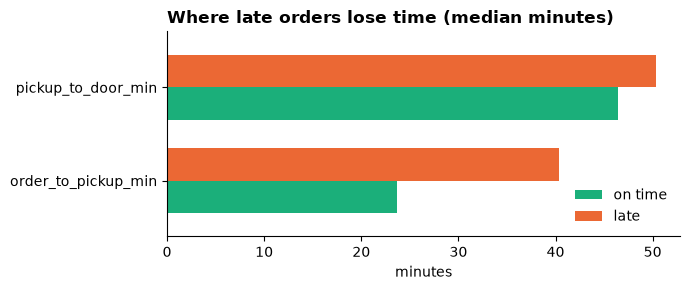

In [5]:
df = order_analysis.copy()
df["traffic"] = df["traffic_bucket"].str.lower()          # 'HIGH' == 'high'
df["hour_band"] = pd.cut(df["created_at"].dt.hour, [0, 12, 15, 18, 21, 24], right=False,
                         labels=["before 12", "12-15", "15-18", "18-21", "21-24"])
# Split each order's journey into two stages
df["order_to_pickup_min"] = (df["pickup_at"] - df["created_at"]).dt.total_seconds() / 60
df["pickup_to_door_min"] = (df["actual_delivery_at"] - df["pickup_at"]).dt.total_seconds() / 60

def compare(col, order=None):
    g = df.groupby(col, observed=True).agg(orders=("order_id", "count"),
                                           late_rate=("is_late", "mean"),
                                           median_delay=("delay_min", "median"))
    if order:
        g = g.reindex(order)
    return g.round({"late_rate": 3, "median_delay": 1})

print("1) Traffic");      display(compare("traffic", ["low", "medium", "high", "severe"]))
print("2) Weather");      display(compare("weather_bucket", ["clear", "rain", "heavy_rain"]))
print("3) Time of day");  display(compare("hour_band"))
print("4) Restaurant: spread of late rate across 60 restaurants")
display(df.groupby("restaurant_id")["is_late"].mean().describe().round(3).to_frame("late_rate"))

# 5) WHERE in the journey does the late order lose time?
stages = df.groupby("is_late")[["order_to_pickup_min", "pickup_to_door_min"]].median().round(1)
stages.index = ["on time", "late"]
print("5) Median minutes per stage, late vs on-time")
display(stages)

# Does pre-pickup time still separate late from on-time *within* each traffic level?
within = df.pivot_table(index="traffic", columns="is_late", values="order_to_pickup_min",
                        aggfunc="median").reindex(["low", "medium", "high", "severe"]).round(1)
within.columns = ["on time: order to pickup", "late: order to pickup"]
display(within)

fig, ax = plt.subplots(figsize=(7, 3))
stages.T.plot(kind="barh", ax=ax, color=["#1baf7a", "#eb6834"], width=0.7)
ax.set_title("Where late orders lose time (median minutes)", loc="left", fontweight="bold")
ax.set_xlabel("minutes"); ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Challenge 2 answer

**Comparisons**

| Dimension | Finding |
|:-|:-|
| Traffic | Late rate rises from **17% (low) to 33% (severe)**. Real, but it is only part of the story |
| Weather | Rain and heavy rain: **34 to 36%** late vs 21% when clear. As strong as traffic |
| Time of day | Flat (19 to 26%). No clear peak-hour effect |
| Restaurant | Wide spread: **4% to 41%** late across 60 restaurants |
| **Journey stage** | Late orders take **+16.7 min longer before pickup** (40.4 vs 23.7) but only **+3.9 min longer on the road** (50.3 vs 46.4) |

**Hypothesis supported by evidence:** most delay accumulates **before the driver picks up the food** (restaurant prep or driver arrival), not in traffic. The pre-pickup gap is about 17 minutes at *every* traffic level, so traffic cannot explain it.

**Alternative we cannot rule out:** traffic could still delay the driver getting *to* the restaurant, which also lands in the "before pickup" stage. We have no "driver arrived at restaurant" event, so we cannot split restaurant prep time from driver travel time (see Challenge 5).

**Association vs causation:** these are associations. Rain, traffic, and slow restaurants may occur together (for example rainy evenings at busy restaurants), so we cannot say any one of them *causes* lateness without controlling for the others.

**Verdict on "traffic is the problem":** partly true, mostly misleading. Traffic is associated with lateness, but the biggest measurable gap is pre-pickup time, which is an operations and restaurant problem that traffic does not explain.

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [6]:
display(tickets.head())

print("Raw complaint categories (note the variants):")
display(tickets["category"].value_counts())

# Representation fixes only, where the meaning is obviously the same
CATEGORY_MAP = {"Late Delivery": "late_delivery", "ETA issue": "eta_changed"}   # after .strip()
t = tickets.copy()
t["category_clean"] = t["category"].str.strip().replace(CATEGORY_MAP)

print("Duplicate ticket_ids:", t["ticket_id"].duplicated().sum(),
      "| fully identical rows:", t.duplicated().sum())
t = t.drop_duplicates("ticket_id", keep="first")
print("Tickets with no order_id:", t["order_id"].isna().sum())

# Which stage of the journey is each complaint about?
STAGE = {"restaurant_delay": "restaurant prep", "ready_but_waiting": "waiting for driver",
         "status_mismatch": "restaurant/app handoff", "driver_not_moving": "on the road",
         "eta_changed": "ETA reliability", "late_delivery": "outcome only"}
t["journey_stage"] = t["category_clean"].map(STAGE)
cats = t["category_clean"].value_counts().to_frame("tickets")
cats["share"] = (cats["tickets"] / cats["tickets"].sum()).round(3)
cats["journey_stage"] = cats.index.map(STAGE)
display(cats)

# System view vs customer view: join tickets to the delivery analysis
merged = t.merge(order_analysis[["order_id", "is_late", "delay_min"]], on="order_id", how="left")
merged["system_says"] = merged["is_late"].map({True: "late (>10 min)", False: "not late"}).fillna("no delivery record")
display(pd.crosstab(merged["category_clean"], merged["system_says"], margins=True))

tickets_on_late = merged["is_late"].eq(True).sum()
print(f"Tickets on orders the system calls late: {tickets_on_late} of {len(merged)} ({tickets_on_late/len(merged):.0%})")
print(f"Late orders that got a ticket: {merged.loc[merged['is_late'].eq(True), 'order_id'].nunique()} of {order_analysis['is_late'].sum()}")
print("'late_delivery' complaints on orders the system says were NOT late:",
      ((merged["category_clean"] == "late_delivery") & merged["is_late"].eq(False)).sum())

print("Delay of those 'late_delivery' complaints the system does not count as late:")
display(merged.loc[(merged["category_clean"] == "late_delivery") & merged["is_late"].eq(False), "delay_min"].describe().round(1).to_frame())

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Raw complaint categories (note the variants):


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket_ids: 1 | fully identical rows: 1
Tickets with no order_id: 3


,tickets,share,journey_stage
category_clean,,,
late_delivery,39,0.194,outcome only
eta_changed,38,0.189,ETA reliability
restaurant_delay,37,0.184,restaurant prep
ready_but_waiting,33,0.164,waiting for driver
status_mismatch,29,0.144,restaurant/app handoff
driver_not_moving,25,0.124,on the road


system_says,late (>10 min),no delivery record,not late,All
category_clean,,,,
driver_not_moving,13,0,12,25
eta_changed,15,2,21,38
late_delivery,24,1,14,39
ready_but_waiting,18,0,15,33
restaurant_delay,19,0,18,37
status_mismatch,17,1,11,29
All,106,4,91,201


Tickets on orders the system calls late: 106 of 201 (53%)
Late orders that got a ticket: 106 of 349
'late_delivery' complaints on orders the system says were NOT late: 14
Delay of those 'late_delivery' complaints the system does not count as late:


,delay_min
count,14.0
mean,1.1
std,6.7
min,-12.3
25%,-5.2
50%,2.6
75%,6.5
max,9.9


### Challenge 3 answer

**1 and 2. What customers complain about.** After merging casing variants (`Late Delivery`, `ETA issue`), there are 6 categories, and **half of all complaints are about the stage before pickup**:

| Journey stage | Categories | Share of tickets |
|:-|:-|:-|
| Before pickup | restaurant_delay, ready_but_waiting, status_mismatch | **49%** |
| ETA reliability | eta_changed | 19% |
| Outcome only | late_delivery | 19% |
| On the road | driver_not_moving | 12% |

**3. Are ticket IDs unique?** No. `T00013` appears twice as a fully identical row (dropped). 3 tickets have no `order_id` and cannot be linked to an order.

**4. Does the customer story match the operational story?** **Yes, and it strengthens it.** Challenge 2 found that late orders lose most of their time before pickup, and customers independently complain most about that stage. Only 12% of complaints are about the driver on the road, which again undercuts "traffic is the problem". Late orders are also about 4x more likely to get a ticket (106 of 349 = 30%, against 91 of 1,146 = 8% for other orders).

**5. What tickets tell us that timestamps cannot:**
* *Why* a stage was slow: "restaurant still preparing" vs "food ready but no rider" are both just "slow pickup" in the timestamps.
* **Process breaks**: `status_mismatch` (app says picking up, restaurant says ready) shows two systems disagreeing.
* **Perceived lateness**: 14 `late_delivery` complaints are on orders that were at most 9.9 min late, or even early (median +2.6 min). Customers feel late earlier than any threshold, and the frequently changing ETA (19% of tickets) makes it worse.

**System view vs customer view**

| | System view (timestamps) | Customer view (tickets) |
|:-|:-|:-|
| Size | 23% of orders late | 201 tickets, 30% of late orders complained |
| Where it goes wrong | Pre-pickup stage (+17 min) | Restaurant and pickup handoff (49%) |
| What it misses | Why the stage was slow | Orders nobody complained about |
| Bias | Only records what is instrumented | Only the unhappy customers speak |

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [7]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [8]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [9]:
# TODO: reliable paginated ingestion

RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

def fetch_all_dispatch_orders():
    """
    Requirements:
    - fetch every page,
    - retry HTTP 500 / 429,
    - preserve successful raw responses,
    - fail clearly on unrecoverable errors,
    - verify final record count.
    """
    records = []

    # Suggested skeleton:
    # page = 1
    # while True:
    #     response = requests.get(...)
    #     if response.status_code in [429, 500]:
    #         ...
    #     response.raise_for_status()
    #     payload = response.json()
    #     save payload
    #     records.extend(payload["data"])
    #     if not payload["has_more"]:
    #         break
    #     page += 1

    return records

# dispatch_records = fetch_all_dispatch_orders()
# print("Retrieved:", len(dispatch_records))

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned |  |  |  |
| Driver at restaurant |  |  |  |
| Picked up |  |  |  |
| Delivered |  |  |  |

In [10]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# TODO: can you find an explicit driver_arrived_at_restaurant event?

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

In [11]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
